<a href="https://colab.research.google.com/github/barbarajunq131/Programas/blob/main/analise_multivariada_UFRRJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving base.csv to base.csv
Arquivo carregado: base.csv

Tabela de variância:
  Componente  Autovalor  Variancia_%  Acumulada_%
0        CP1     5.3920      51.9227      51.9227
1        CP2     2.0425      19.6687      71.5914
2        CP3     1.6854      16.2296      87.8210
3        CP4     0.6143       5.9158      93.7368
4        CP5     0.2197       2.1157      95.8525
5        CP6     0.1673       1.6114      97.4639
6        CP7     0.1501       1.4454      98.9093
7        CP8     0.0686       0.6610      99.5703
8        CP9     0.0284       0.2736      99.8439
9       CP10     0.0162       0.1561     100.0000

Correlações com CP1 e CP2:
                           CP1     CP2
t_m10a17_filho          0.6026  0.6775
t_mchefe_fundin_fmenor  0.6553  0.2398
t_analf_15m             0.8928 -0.4262
t_cdom_fundin           0.9426 -0.2539
t_p15a24_nada           0.9647 -0.2099
t_desocup18m            0.0579 -0.3659
pea18m                 -0.6173 -0.4031
t_carteira_18m         -0.9158 -

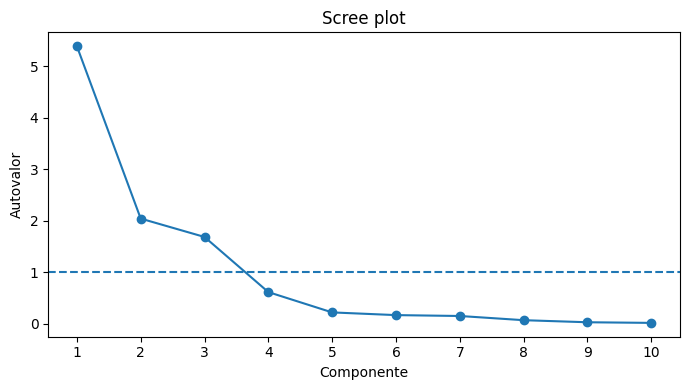

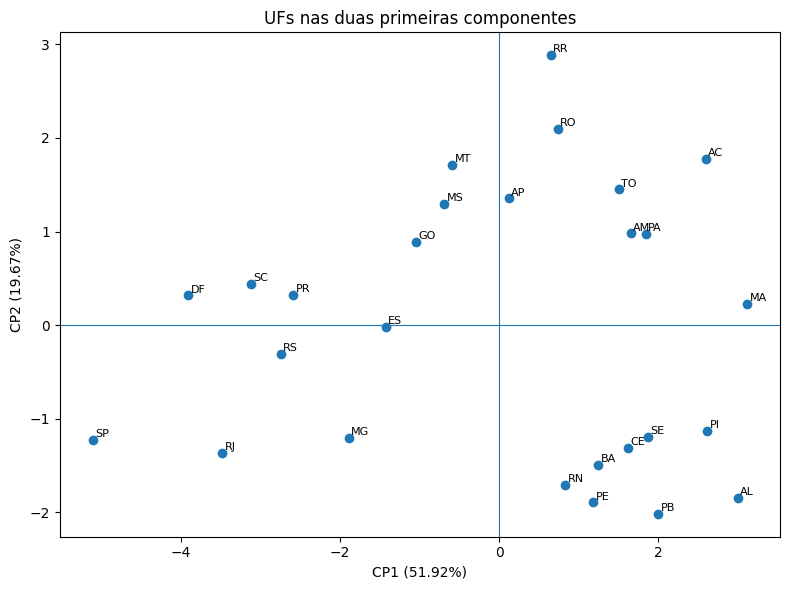

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import files

# 1. Fazer upload do arquivo CSV no Colab
uploaded = files.upload()

# 2. Descobrir o nome do arquivo enviado
nome_arquivo = list(uploaded.keys())[0]
print(f"Arquivo carregado: {nome_arquivo}")

# 3. Leitura da base
df = pd.read_csv(nome_arquivo)

# 4. Separação da coluna identificadora e das variáveis numéricas
ufs = df["uf"]
X = df.drop(columns=["uf"])

# 5. Garantir que todas as colunas restantes sejam numéricas
X = X.apply(pd.to_numeric, errors="coerce")

# 6. Verificar valores ausentes gerados na conversão
if X.isnull().sum().sum() > 0:
    print("Atenção: existem valores ausentes após conversão para numérico.")
    print(X.isnull().sum()[X.isnull().sum() > 0])
    X = X.fillna(X.mean())

# 7. Padronização
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# 8. ACP
pca = PCA()
scores = pca.fit_transform(Z)

# 9. Resultados principais
autovalores = pca.explained_variance_
variancia = pca.explained_variance_ratio_ * 100
variancia_acumulada = np.cumsum(variancia)

tabela_variancia = pd.DataFrame({
    "Componente": [f"CP{i+1}" for i in range(len(autovalores))],
    "Autovalor": autovalores,
    "Variancia_%": variancia,
    "Acumulada_%": variancia_acumulada
})

print("\nTabela de variância:")
print(tabela_variancia.round(4))

# 10. Cargas fatoriais
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"CP{i+1}" for i in range(X.shape[1])]
)

# 11. Correlações variáveis-componentes
corr_vars_comp = loadings.copy()
for i, col in enumerate(corr_vars_comp.columns):
    corr_vars_comp[col] = loadings[col] * np.sqrt(autovalores[i])

print("\nCorrelações com CP1 e CP2:")
print(corr_vars_comp[["CP1", "CP2"]].round(4))

# 12. Escores das UFs
scores_df = pd.DataFrame(scores[:, :2], columns=["CP1", "CP2"])
scores_df["uf"] = ufs.values

print("\nTop 4 UFs em CP1:")
print(scores_df.sort_values("CP1", ascending=False).head(4))

# 13. Scree plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(autovalores) + 1), autovalores, marker="o")
plt.axhline(1, linestyle="--")
plt.xticks(range(1, len(autovalores) + 1))
plt.xlabel("Componente")
plt.ylabel("Autovalor")
plt.title("Scree plot")
plt.tight_layout()
plt.show()

# 14. Dispersão das UFs em CP1 x CP2
plt.figure(figsize=(8, 6))
plt.scatter(scores_df["CP1"], scores_df["CP2"])

for _, row in scores_df.iterrows():
    plt.text(row["CP1"] + 0.03, row["CP2"] + 0.03, row["uf"], fontsize=8)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(f"CP1 ({variancia[0]:.2f}%)")
plt.ylabel(f"CP2 ({variancia[1]:.2f}%)")
plt.title("UFs nas duas primeiras componentes")
plt.tight_layout()
plt.show()